# Wine Alcohol Content Prediction
### Comparing Linear Regression, Polynomial Regression, and KNN

In this notebook we will:
1. Load the wine dataset
2. Explore and clean the data
3. Train 3 models: Linear Regression, Polynomial Regression, and KNN Regression
4. Compare them using R2 Score, MSE, and RMSE

**Dataset:** `wine.csv`
**Goal:** Predict the `Alcohol` percentage of a wine using its chemical properties
(`Color intensity`, `Total phenols`, `Flavanoids`, `OD280/OD315 of diluted wines`).


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error


## Step 2: Load the Dataset

In [2]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv("wine.csv")

# Remove any extra spaces in column names
df.columns = [c.strip() for c in df.columns]

# Show the first 5 rows
df.head()


,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Step 3: Explore the Data

Before training any model, it's important to understand the data.


In [3]:
# Basic information about the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proline         

In [4]:
# Check for missing values
df.isnull().sum()


class                           0
Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64

In [5]:
# Summary statistics
df.describe()


,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


We will use 4 features to predict `Alcohol`:
- `Color intensity`
- `Total phenols`
- `Flavanoids`
- `OD280/OD315 of diluted wines`


## Step 4: Preprocessing

In [6]:
# Separate features (X) and target (y)
features = ["Color intensity", "Total phenols", "Flavanoids", "OD280/OD315 of diluted wines"]
X = df[features]
y = df["Alcohol"]

# Split into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 142
Testing samples: 36


In [7]:
# Scale the features (this helps KNN a lot, and doesn't hurt Linear/Polynomial Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 5: A Helper Function to Evaluate Models

We will use this same function to check R2 Score, MSE, and RMSE for every model.


In [8]:
def evaluate_model(name, y_true, y_pred, results_list):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"--- {name} ---")
    print("R2 Score:", round(r2, 4))
    print("MSE:", round(mse, 4))
    print("RMSE:", round(rmse, 4))
    print()

    results_list.append({"Model": name, "R2 Score": r2, "MSE": mse, "RMSE": rmse})

# This list will store the results of all models so we can compare them later
results = []


## Step 6: Model 1 - Linear Regression

In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

evaluate_model("Linear Regression", y_test, y_pred_lr, results)


--- Linear Regression ---
R2 Score: 0.5678
MSE: 0.258
RMSE: 0.508



## Step 7: Model 2 - Polynomial Regression

Polynomial Regression is just Linear Regression applied to features that have been
"expanded" to include squared terms and interactions.


In [10]:
# Create polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Train a normal Linear Regression model on these new polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

evaluate_model("Polynomial Regression", y_test, y_pred_poly, results)


--- Polynomial Regression ---
R2 Score: 0.5772
MSE: 0.2524
RMSE: 0.5024



## Step 8: Model 3 - K-Nearest Neighbors (KNN) Regression

In [11]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

evaluate_model("KNN Regression", y_test, y_pred_knn, results)


--- KNN Regression ---
R2 Score: 0.6439
MSE: 0.2126
RMSE: 0.4611



## Step 9: Compare All Models

In [12]:
results_df = pd.DataFrame(results)
results_df


,Model,R2 Score,MSE,RMSE
0,Linear Regression,0.567842,0.258014,0.507951
1,Polynomial Regression,0.577209,0.252421,0.502416
2,KNN Regression,0.643924,0.212590,0.461075


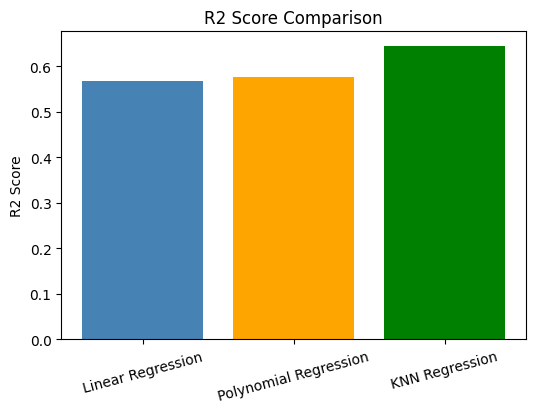

In [13]:
# Visual comparison of R2 Scores
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["R2 Score"], color=["steelblue", "orange", "green"])
plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.show()


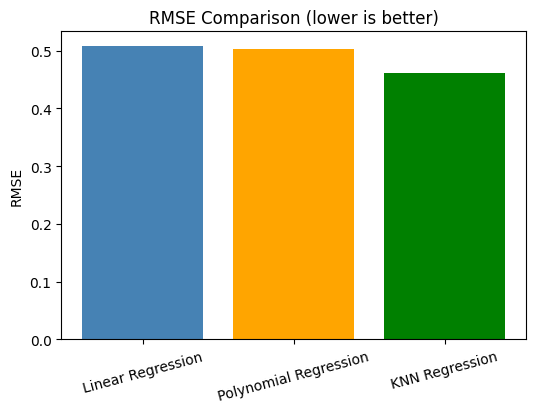

In [14]:
# Visual comparison of RMSE
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["RMSE"], color=["steelblue", "orange", "green"])
plt.title("RMSE Comparison (lower is better)")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()


## Step 10: Conclusion

Look at the table above:
- **Higher R2 Score** = better (closer to 1 means the model explains the data well)
- **Lower MSE and RMSE** = better (means smaller prediction errors)

Compare the three models and note which one performed best on this dataset. Since this
is a different dataset with different relationships between features, the best model
here might not be the same as the best model in the housing notebook — that's normal!
